
# Teaching notebook: testing Theorem 2 with mixed \(n\)-gram and \(r\)-gram agents

This notebook is a **teaching tool** for the strong form of Theorem 2.

It studies a public law \(\rho_t\) on length-\(r\) strings and asks whether, after many generations,
that public \(r\)-gram law becomes the same as the law generated by the fitted \(n\)-gram next-token predictor.

The notebook uses the **block-law / window-marginal** convention:

- a distribution on length-\(L\) strings induces window marginals for \(k=1,\dots,L\),
- these window marginals define a longest-suffix **back-off** next-token rule,
- rolling that next-token rule forward from the empty start context produces a new law on strings.

This is the exact population-map viewpoint behind the theorem-2 discussion.

## The three maps

We use three maps.

1. **Public \(r\)-law**  
   \[
   \rho_t \in \Delta(\Sigma^r)
   \]
   is the current distribution on published \(r\)-grams.

2. **Refit map \(R_n\)**  
   From \(\rho_t\), compute the induced window marginals up to order \(n\), then refit the order-\(n\) next-token predictor:
   \[
   q_t = R_n(\rho_t).
   \]

3. **Rollout map \(G_{n\to r}\)**  
   Roll the fitted \(n\)-gram predictor forward to length \(r\):
   \[
   \widetilde\rho_t = G_{n\to r}(q_t).
   \]

The strong form of Theorem 2 says that, in the descriptive mixed-agent setting, the public \(r\)-law should approach a fixed point that is also **\(n\)-generated**:
\[
\rho_t \approx G_{n\to r}(R_n(\rho_t)).
\]

## The update studied here

The default mode is the one discussed in the conversation:

- a fraction \(\beta\) of agents are **look-ahead agents** and simply republish according to the current public \(r\)-law,
- a fraction \(1-\beta\) are ordinary **one-shot \(n\)-gram agents** and publish according to \(G_{n\to r}(R_n(\rho_t))\),
- a replacement factor \(\alpha\) mixes retained public law and newly produced law.

So the update is
\[
\rho_{t+1}
=
(1-\alpha)\rho_t
+
\alpha\Bigl[
(1-\beta)\,G_{n\to r}(R_n(\rho_t))
+
\beta\,\rho_t
\Bigr].
\]

In the fully replaced case \(\alpha=1\), this simplifies to
\[
\rho_{t+1} = (1-\beta)\,G_{n\to r}(R_n(\rho_t)) + \beta\,\rho_t.
\]

## The four practical diagnostics

The notebook computes and saves four diagnostics.

1. **Strong global gap**
   \[
   \|\rho_t - G_{n\to r}(R_n(\rho_t))\|_1.
   \]
   If this goes to \(0\), then the public \(r\)-gram law is becoming \(n\)-generated.

2. **Strong KL gap**
   \[
   D_{\mathrm{KL}}\!\bigl(\rho_t \,\|\, G_{n\to r}(R_n(\rho_t))\bigr).
   \]
   This tells you how much information is lost when you replace the public \(r\)-law by the fitted \(n\)-gram rollout law.

3. **Prefix-conditional check**
   For each prefix of length \(n\), compare the conditional distribution of the remaining \(r-n\) tokens under
   the public law and under the fitted \(n\)-gram rollout law.
   This shows **where** the mismatch lives, without drowning the reader in all \(r\)-grams.

4. **Largest mismatched \(r\)-grams**
   Find the specific \(r\)-grams with the largest absolute discrepancy
   \[
   |\rho_t(x) - G_{n\to r}(R_n(\rho_t))(x)|.
   \]

A special bonus in the default `descriptive_prev_r_direct` mode is the exact identity
\[
\rho_{t+1} - \rho_t
=
\alpha(1-\beta)\Bigl(G_{n\to r}(R_n(\rho_t)) - \rho_t\Bigr),
\]
so the generation-to-generation step size is exactly proportional to the strong theorem-2 gap.



## How to use this notebook

1. Set the user parameters in the next cell.
2. Run the notebook.
3. Read the summary, then the global-gap plots, then the prefix table, and finally the top mismatched \(r\)-grams.

### Recommended theorem-2 setting

For the strongest theorem-2 experiment, use:

- `lookahead_mode = "descriptive_prev_r_direct"`
- `0 < beta_mix < 1`
- `alpha_replace = 1.0`
- `min_context_mass = 0.0`
- `rollout_mode = "exact"` when feasible

### Interpreting the output

- If the **strong \(L^1\) gap** and **strong KL gap** both go to zero, then the public \(r\)-law is becoming indistinguishable from the \(r\)-law generated by the fitted \(n\)-gram predictor.
- If the **prefix-conditional** discrepancies are small, then once the first \(n\) tokens are fixed, the rest of the \(r\)-gram is being generated the same way in both descriptions.
- If the **largest mismatched \(r\)-grams** become tiny, then there are no important string-level counterexamples left.
- In the default descriptive mode, the notebook also checks the exact identity
  \[
  \|\rho_{t+1}-\rho_t\|_1 = \alpha(1-\beta)\,\|\rho_t - G_{n\to r}(R_n(\rho_t))\|_1,
  \]
  which is a strong implementation check.

### Important note

This notebook tests a **precise population-map model**.  
It does not prove the theorem, but it does let you test the exact strong diagnostic implied by the theorem:
\[
\rho_t \stackrel{?}{\approx} G_{n\to r}(R_n(\rho_t)).
\]


In [1]:

# --- User configuration ---

# Vocabulary and orders
V = 10
n = 3
r = 7                 # should satisfy r >= n

# Seed n-gram law q_0
# Choices:
#   "random_support_uniform"
#   "random_support_dirichlet"
#   "random_text"
seed_init_mode = "random_support_uniform"
seed_support_size = 100
seed_text_length = 5000
seed = 1

# Initial public r-law rho_0
# Choices:
#   "induced_from_seed_q"   (recommended)
#   "random_support_uniform"
#   "random_support_dirichlet"
#   "random_text"
initial_public_r_mode = "induced_from_seed_q"
initial_r_support_size = 60
initial_r_text_length = 8000

# Mixed-population parameters
alpha_replace = 1.0       # fraction of the public r-law replaced each generation
beta_mix = 0.80           # fraction of new material produced by r-agents

# Look-ahead / publication mode
# Choices:
#   "descriptive_prev_r_direct"   -> theorem-2 default
#   "descriptive_prev_r_rollout"  -> r-agents also apply their own back-off rollout
#   "descriptive_from_current_n"  -> r-agents collapse back to the current n-law
#   "normative_fixed_direct"      -> counterexample / stress-test mode
lookahead_mode = "descriptive_prev_r_direct"

# If you use a normative mode, pick a fixed target r-law here.
# Choices:
#   "seed_induced_from_q"
#   "initial_public_r"
#   "random_support_uniform"
#   "random_support_dirichlet"
#   "random_text"
normative_target_mode = "seed_induced_from_q"
normative_target_support_size = 60
normative_target_text_length = 8000

# Iteration controls
iterations = 40
tol = 1e-8

# Rollout controls
# Choices:
#   "exact"   -> exact sparse rollout; best for theorem-faithful experiments
#   "auto"    -> exact if feasible, Monte Carlo fallback otherwise
#   "sample"  -> Monte Carlo approximation
rollout_mode = "exact"
exact_max_states = 500_000
num_rollout_samples = 50_000

# Back-off threshold
# Keep this at 0.0 for theorem-faithful longest-suffix back-off.
min_context_mass = 0.0

# Reporting controls
top_k_rgrams = 20
top_k_prefixes = 20
run_local_probe = False          # optional numerical probe; not a proof
probe_count = 10
probe_epsilon = 1e-6



## Core helper functions

The next cell defines:

- initialization of sparse \(n\)-gram and \(r\)-gram laws,
- induced window marginals,
- longest-suffix back-off,
- exact and sampled rollout,
- the mixed theorem-2 update,
- the saved diagnostics and teaching summaries.


In [2]:

import math
import json
from pathlib import Path
from collections import defaultdict, Counter
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

plt.rcParams["figure.dpi"] = 140

def format_gram(g):
    return "".join(str(x) for x in g)

def normalize_distribution(q):
    total = float(sum(q.values()))
    if total <= 0:
        raise ValueError("Distribution has non-positive total mass.")
    return {k: float(v / total) for k, v in q.items() if v > 0}

def l1_distance(q, p):
    keys = set(q) | set(p)
    return float(sum(abs(q.get(k, 0.0) - p.get(k, 0.0)) for k in keys))


def kl_divergence(q, p):
    """Exact KL(q || p). Returns +inf if p is zero on a positive-mass point of q."""
    kl = 0.0
    for k, qv in q.items():
        if qv <= 0:
            continue
        pv = p.get(k, 0.0)
        if pv <= 0:
            return float("inf")
        kl += qv * math.log(qv / pv)
    if kl < 0 and abs(kl) < 1e-14:
        kl = 0.0
    return float(kl)

def entropy(q):
    return float(-sum(v * math.log(v) for v in q.values() if v > 0))

def sample_unique_ngrams(V, L, R, rng):
    total = V ** L
    if R > total:
        raise ValueError(f"support_size={R} exceeds V^L={total}.")
    chosen = set()
    while len(chosen) < R:
        gram = tuple(rng.integers(0, V, size=L).tolist())
        chosen.add(gram)
    return list(chosen)

def initialize_distribution(V, L, init_mode, support_size=50, text_length=5000, seed=0):
    rng = np.random.default_rng(seed)

    if init_mode == "random_support_uniform":
        grams = sample_unique_ngrams(V, L, support_size, rng)
        return {g: 1.0 / len(grams) for g in grams}

    if init_mode == "random_support_dirichlet":
        grams = sample_unique_ngrams(V, L, support_size, rng)
        weights = rng.dirichlet(np.ones(len(grams)))
        return {g: float(w) for g, w in zip(grams, weights)}

    if init_mode == "random_text":
        if text_length < L:
            raise ValueError("text_length must be at least L.")
        text = rng.integers(0, V, size=text_length).tolist()
        counts = Counter()
        for i in range(text_length - L + 1):
            counts[tuple(text[i:i+L])] += 1
        return normalize_distribution(counts)

    raise ValueError(f"Unknown init_mode: {init_mode}")

def induced_window_marginals(q, L):
    """
    Given a law q on length-L strings, compute the induced contiguous-window marginals
    for k = 1, ..., L by averaging uniformly over all window positions.
    """
    mu = [{(): 1.0}]
    for k in range(1, L + 1):
        counts = defaultdict(float)
        windows_per_block = L - k + 1
        for gram, p in q.items():
            w = p / windows_per_block
            for start in range(windows_per_block):
                counts[gram[start:start+k]] += w
        mu.append(normalize_distribution(counts))
    return mu

def next_token_row(prefix, mu, V, order, min_context_mass=0.0, row_cache=None):
    """
    Longest-suffix back-off using the induced window marginals of a law on length-'order' strings.
    Returns:
        row: dict mapping token -> probability
        L:   length of the suffix-context actually used
        ctx: the suffix-context itself
    """
    prefix = tuple(prefix)
    if row_cache is not None and prefix in row_cache:
        return row_cache[prefix]

    maxL = min(len(prefix), order - 1)
    for L in range(maxL, -1, -1):
        ctx = prefix[-L:] if L > 0 else ()
        ctx_mass = mu[L].get(ctx, 0.0) if L > 0 else 1.0
        if ctx_mass <= min_context_mass:
            continue

        row = {}
        total = 0.0
        for a in range(V):
            ext = ctx + (a,)
            ext_mass = mu[L + 1].get(ext, 0.0)
            if ext_mass > 0:
                prob = ext_mass / ctx_mass
                row[a] = prob
                total += prob

        if total > 0:
            inv = 1.0 / total
            for a in list(row.keys()):
                row[a] *= inv
            result = (row, L, ctx)
            if row_cache is not None:
                row_cache[prefix] = result
            return result

    fallback = ({a: 1.0 / V for a in range(V)}, 0, ())
    if row_cache is not None:
        row_cache[prefix] = fallback
    return fallback

class ExactTooLarge(RuntimeError):
    pass

def exact_rollout_from_law(q, V, order, out_length, min_context_mass=0.0, max_states=200_000):
    """
    Roll a law on length-'order' strings forward into a law on length-'out_length' strings,
    using longest-suffix back-off from the induced window marginals.
    """
    mu = induced_window_marginals(q, order)
    frontier = {(): 1.0}
    row_cache = {}

    for _ in range(out_length):
        new = defaultdict(float)
        for prefix, p in frontier.items():
            row, _, _ = next_token_row(
                prefix, mu, V, order,
                min_context_mass=min_context_mass,
                row_cache=row_cache,
            )
            for a, pa in row.items():
                new[prefix + (a,)] += p * pa
        frontier = dict(new)

        if len(frontier) > max_states:
            raise ExactTooLarge(
                f"Exact rollout exceeded max_states={max_states}; "
                f"current support = {len(frontier)}."
            )

    return normalize_distribution(frontier)

def sample_rollout_from_law(q, V, order, out_length, min_context_mass=0.0,
                            num_samples=20_000, seed=0):
    mu = induced_window_marginals(q, order)
    rng = np.random.default_rng(seed)
    row_cache = {}
    counts = Counter()

    for _ in range(num_samples):
        prefix = []
        for _step in range(out_length):
            row, _, _ = next_token_row(
                tuple(prefix), mu, V, order,
                min_context_mass=min_context_mass,
                row_cache=row_cache,
            )
            tokens = np.fromiter(row.keys(), dtype=int)
            probs = np.fromiter(row.values(), dtype=float)
            probs = probs / probs.sum()
            a = int(rng.choice(tokens, p=probs))
            prefix.append(a)
        counts[tuple(prefix)] += 1

    return normalize_distribution(counts)

def rollout_from_law(q, V, order, out_length, rollout_mode="auto",
                     exact_max_states=200_000, num_rollout_samples=20_000,
                     min_context_mass=0.0, seed=0):
    if rollout_mode == "exact":
        return (
            exact_rollout_from_law(
                q, V, order, out_length,
                min_context_mass=min_context_mass,
                max_states=exact_max_states,
            ),
            "exact",
        )
    if rollout_mode == "sample":
        return (
            sample_rollout_from_law(
                q, V, order, out_length,
                min_context_mass=min_context_mass,
                num_samples=num_rollout_samples,
                seed=seed,
            ),
            "sample",
        )
    if rollout_mode == "auto":
        try:
            dist = exact_rollout_from_law(
                q, V, order, out_length,
                min_context_mass=min_context_mass,
                max_states=exact_max_states,
            )
            return dist, "exact"
        except ExactTooLarge:
            dist = sample_rollout_from_law(
                q, V, order, out_length,
                min_context_mass=min_context_mass,
                num_samples=num_rollout_samples,
                seed=seed,
            )
            return dist, "sample"
    raise ValueError(f"Unknown rollout_mode: {rollout_mode}")

def project_to_n_from_r(r_dist, n):
    if not r_dist:
        raise ValueError("Cannot project an empty distribution.")
    r_local = len(next(iter(r_dist)))
    if n > r_local:
        raise ValueError(f"Cannot project to n={n} from r={r_local}.")
    mu = induced_window_marginals(r_dist, r_local)
    return mu[n]

def mix_distributions(*weighted_terms):
    counts = defaultdict(float)
    for weight, q in weighted_terms:
        if weight == 0:
            continue
        for k, v in q.items():
            counts[k] += weight * v
    return normalize_distribution(counts)

def prepare_target_r(V, r, target_mode, seed_q, seed_rho, support_size, text_length, seed,
                     rollout_mode="exact", exact_max_states=200_000, num_rollout_samples=20_000,
                     min_context_mass=0.0):
    if target_mode == "seed_induced_from_q":
        q_order = len(next(iter(seed_q)))
        target_r, used = rollout_from_law(
            seed_q, V, q_order, r,
            rollout_mode=rollout_mode,
            exact_max_states=exact_max_states,
            num_rollout_samples=num_rollout_samples,
            min_context_mass=min_context_mass,
            seed=seed,
        )
        return target_r, f"seed_induced_from_q_{used}"

    if target_mode == "initial_public_r":
        return dict(seed_rho), "initial_public_r"

    if target_mode in {"random_support_uniform", "random_support_dirichlet", "random_text"}:
        return initialize_distribution(
            V, r,
            init_mode=target_mode,
            support_size=support_size,
            text_length=text_length,
            seed=seed,
        ), target_mode

    raise ValueError(f"Unknown target_mode: {target_mode}")

def apply_r_agent(lookahead_mode, rho_t, q_t, V, n, r, target_r=None,
                  rollout_mode="auto", exact_max_states=200_000,
                  num_rollout_samples=20_000, min_context_mass=0.0, seed=0):
    if lookahead_mode == "descriptive_prev_r_direct":
        return dict(rho_t), "direct_prev_r"

    if lookahead_mode == "descriptive_prev_r_rollout":
        dist, used = rollout_from_law(
            rho_t, V, r, r,
            rollout_mode=rollout_mode,
            exact_max_states=exact_max_states,
            num_rollout_samples=num_rollout_samples,
            min_context_mass=min_context_mass,
            seed=seed,
        )
        return dist, f"prev_r_rollout_{used}"

    if lookahead_mode == "descriptive_from_current_n":
        dist, used = rollout_from_law(
            q_t, V, n, r,
            rollout_mode=rollout_mode,
            exact_max_states=exact_max_states,
            num_rollout_samples=num_rollout_samples,
            min_context_mass=min_context_mass,
            seed=seed,
        )
        return dist, f"current_n_induced_{used}"

    if lookahead_mode == "normative_fixed_direct":
        if target_r is None:
            raise ValueError("target_r is required for normative_fixed_direct.")
        return dict(target_r), "normative_direct"

    raise ValueError(f"Unknown lookahead_mode: {lookahead_mode}")

def theorem2_public_map(rho_t, V, n, r, alpha_replace, beta_mix, lookahead_mode,
                        target_r=None, rollout_mode="exact",
                        exact_max_states=200_000, num_rollout_samples=20_000,
                        min_context_mass=0.0, seed=0):
    q_t = project_to_n_from_r(rho_t, n)
    generated_from_n, mode_n = rollout_from_law(
        q_t, V, n, r,
        rollout_mode=rollout_mode,
        exact_max_states=exact_max_states,
        num_rollout_samples=num_rollout_samples,
        min_context_mass=min_context_mass,
        seed=seed,
    )
    r_agent, mode_r = apply_r_agent(
        lookahead_mode=lookahead_mode,
        rho_t=rho_t,
        q_t=q_t,
        V=V,
        n=n,
        r=r,
        target_r=target_r,
        rollout_mode=rollout_mode,
        exact_max_states=exact_max_states,
        num_rollout_samples=num_rollout_samples,
        min_context_mass=min_context_mass,
        seed=seed + 1,
    )
    mixed_new = mix_distributions((1.0 - beta_mix, generated_from_n), (beta_mix, r_agent))
    rho_next = mix_distributions((1.0 - alpha_replace, rho_t), (alpha_replace, mixed_new))
    return rho_next, q_t, generated_from_n, mode_n, mode_r

def iterate_theorem2_map(seed_q, V, n, r, alpha_replace=1.0, beta_mix=0.3,
                         iterations=20, lookahead_mode="descriptive_prev_r_direct",
                         initial_public_r_mode="induced_from_seed_q",
                         initial_r_support_size=300, initial_r_text_length=5000,
                         normative_target_mode="seed_induced_from_q",
                         normative_target_support_size=300,
                         normative_target_text_length=5000,
                         rollout_mode="exact", exact_max_states=200_000,
                         num_rollout_samples=20_000, min_context_mass=0.0,
                         seed=0):
    if initial_public_r_mode == "induced_from_seed_q":
        rho0, initial_public_mode_used = rollout_from_law(
            seed_q, V, n, r,
            rollout_mode=rollout_mode,
            exact_max_states=exact_max_states,
            num_rollout_samples=num_rollout_samples,
            min_context_mass=min_context_mass,
            seed=seed,
        )
    elif initial_public_r_mode in {"random_support_uniform", "random_support_dirichlet", "random_text"}:
        rho0 = initialize_distribution(
            V, r,
            init_mode=initial_public_r_mode,
            support_size=initial_r_support_size,
            text_length=initial_r_text_length,
            seed=seed,
        )
        initial_public_mode_used = "direct"
    else:
        raise ValueError(f"Unknown initial_public_r_mode: {initial_public_r_mode}")

    target_r = None
    target_info = None
    if lookahead_mode.startswith("normative"):
        target_r, target_info = prepare_target_r(
            V=V,
            r=r,
            target_mode=normative_target_mode,
            seed_q=seed_q,
            seed_rho=rho0,
            support_size=normative_target_support_size,
            text_length=normative_target_text_length,
            seed=seed + 123,
            rollout_mode=rollout_mode,
            exact_max_states=exact_max_states,
            num_rollout_samples=num_rollout_samples,
            min_context_mass=min_context_mass,
        )

    rho_t = normalize_distribution(rho0)
    q_t = project_to_n_from_r(rho_t, n)

    history = []
    states = [
        {
            "generation": 0,
            "rho_r": rho_t,
            "q_n": q_t,
        }
    ]

    for gen in range(iterations):
        generated_from_n, mode_n = rollout_from_law(
            q_t, V, n, r,
            rollout_mode=rollout_mode,
            exact_max_states=exact_max_states,
            num_rollout_samples=num_rollout_samples,
            min_context_mass=min_context_mass,
            seed=seed + 1000 + gen,
        )

        strong_gap_l1 = l1_distance(rho_t, generated_from_n)
        strong_gap_kl = kl_divergence(rho_t, generated_from_n)

        mismatch_keys = set(rho_t) | set(generated_from_n)
        worst_key = max(mismatch_keys, key=lambda g: abs(rho_t.get(g, 0.0) - generated_from_n.get(g, 0.0)))
        worst_abs = abs(rho_t.get(worst_key, 0.0) - generated_from_n.get(worst_key, 0.0))

        r_agent, mode_r = apply_r_agent(
            lookahead_mode=lookahead_mode,
            rho_t=rho_t,
            q_t=q_t,
            V=V,
            n=n,
            r=r,
            target_r=target_r,
            rollout_mode=rollout_mode,
            exact_max_states=exact_max_states,
            num_rollout_samples=num_rollout_samples,
            min_context_mass=min_context_mass,
            seed=seed + 3000 + gen,
        )

        mixed_new = mix_distributions((1.0 - beta_mix, generated_from_n), (beta_mix, r_agent))
        rho_next = mix_distributions((1.0 - alpha_replace, rho_t), (alpha_replace, mixed_new))
        q_next = project_to_n_from_r(rho_next, n)

        r_step_l1 = l1_distance(rho_next, rho_t)
        n_step_l1 = l1_distance(q_next, q_t)

        if lookahead_mode == "descriptive_prev_r_direct" and alpha_replace * (1.0 - beta_mix) > 0:
            implied_strong = r_step_l1 / (alpha_replace * (1.0 - beta_mix))
            identity_error = abs(implied_strong - strong_gap_l1)
        else:
            implied_strong = float("nan")
            identity_error = float("nan")

        history.append(
            {
                "generation": gen,
                "support_r": len(rho_t),
                "entropy_r": entropy(rho_t),
                "support_n": len(q_t),
                "entropy_n": entropy(q_t),
                "strong_gap_l1": strong_gap_l1,
                "strong_gap_kl": strong_gap_kl,
                "max_rgram_abs_diff": worst_abs,
                "top_mismatch_rgram": format_gram(worst_key),
                "r_step_l1": r_step_l1,
                "n_step_l1": n_step_l1,
                "implied_strong_from_step": implied_strong,
                "identity_relation_error": identity_error,
                "n_rollout_mode": mode_n,
                "r_agent_mode": mode_r,
            }
        )

        rho_t = rho_next
        q_t = q_next
        states.append(
            {
                "generation": gen + 1,
                "rho_r": rho_t,
                "q_n": q_t,
                "generated_from_n": generated_from_n,
            }
        )

    hist = pd.DataFrame(history)
    return {
        "history": hist,
        "states": states,
        "initial_public_mode_used": initial_public_mode_used,
        "target_r": target_r,
        "target_info": target_info,
    }

def distribution_to_frame(q, label):
    rows = []
    for gram, p in q.items():
        rows.append({"gram": format_gram(gram), label: p})
    return pd.DataFrame(rows).sort_values(label, ascending=False).reset_index(drop=True)

def top_mismatch_table(public_r, generated_r, top_k=20):
    rows = []
    for gram in set(public_r) | set(generated_r):
        rp = public_r.get(gram, 0.0)
        gp = generated_r.get(gram, 0.0)
        rows.append(
            {
                "rgram": format_gram(gram),
                "public_prob": rp,
                "generated_prob": gp,
                "signed_diff": rp - gp,
                "abs_diff": abs(rp - gp),
            }
        )
    df = pd.DataFrame(rows).sort_values("abs_diff", ascending=False).reset_index(drop=True)
    return df.head(top_k), df

def prefix_conditional_diagnostics(public_r, generated_r, prefix_len, top_k=20):
    public_mass = defaultdict(float)
    generated_mass = defaultdict(float)
    public_suffix = defaultdict(lambda: defaultdict(float))
    generated_suffix = defaultdict(lambda: defaultdict(float))

    for gram, p in public_r.items():
        prefix = gram[:prefix_len]
        suffix = gram[prefix_len:]
        public_mass[prefix] += p
        public_suffix[prefix][suffix] += p

    for gram, p in generated_r.items():
        prefix = gram[:prefix_len]
        suffix = gram[prefix_len:]
        generated_mass[prefix] += p
        generated_suffix[prefix][suffix] += p

    rows = []
    all_prefixes = set(public_mass) | set(generated_mass)

    for prefix in all_prefixes:
        mp = public_mass.get(prefix, 0.0)
        mg = generated_mass.get(prefix, 0.0)

        prefix_l1_contribution = 0.0
        for suffix in set(public_suffix[prefix]) | set(generated_suffix[prefix]):
            prefix_l1_contribution += abs(
                public_suffix[prefix].get(suffix, 0.0) - generated_suffix[prefix].get(suffix, 0.0)
            )

        if mp > 0 and mg > 0:
            cond_public = normalize_distribution(public_suffix[prefix])
            cond_generated = normalize_distribution(generated_suffix[prefix])
            suffix_l1 = l1_distance(cond_public, cond_generated)
            suffix_kl = kl_divergence(cond_public, cond_generated)
        elif mp == 0 and mg == 0:
            suffix_l1 = 0.0
            suffix_kl = 0.0
        else:
            suffix_l1 = 2.0
            suffix_kl = float("inf") if mp > 0 else 0.0

        rows.append(
            {
                "prefix": format_gram(prefix),
                "public_prefix_mass": mp,
                "generated_prefix_mass": mg,
                "prefix_mass_abs_diff": abs(mp - mg),
                "prefix_l1_contribution": prefix_l1_contribution,
                "suffix_l1": suffix_l1,
                "suffix_kl": suffix_kl,
                "weighted_suffix_l1": mp * suffix_l1,
            }
        )

    df = pd.DataFrame(rows).sort_values("prefix_l1_contribution", ascending=False).reset_index(drop=True)
    return df.head(top_k), df

def make_run_tag(V, n, r, alpha_replace, beta_mix, lookahead_mode, seed, rollout_mode):
    def fmt(x):
        return str(x).replace(".", "p")
    short_mode = {
        "descriptive_prev_r_direct": "descPrevRDirect",
        "descriptive_prev_r_rollout": "descPrevRRoll",
        "descriptive_from_current_n": "descFromCurrentN",
        "normative_fixed_direct": "normFixedDirect",
    }.get(lookahead_mode, lookahead_mode)
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    return f"thm2_V{V}_n{n}_r{r}_a{fmt(alpha_replace)}_b{fmt(beta_mix)}_{short_mode}_seed{seed}_{rollout_mode}_{stamp}"

def save_plot(fig, path):
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    plt.close(fig)

def finite_or_nan(x):
    return np.nan if (isinstance(x, float) and (math.isinf(x) or math.isnan(x))) else x

def summarize_prefix_check(prefix_df):
    if prefix_df.empty:
        return "No prefixes were available for the prefix-conditional check."
    weighted_mean = float(np.average(prefix_df["suffix_l1"], weights=np.maximum(prefix_df["public_prefix_mass"], 1e-16)))
    worst = prefix_df.iloc[0]
    return (
        f"Mass-weighted mean suffix L1 = {weighted_mean:.6e}. "
        f"Worst prefix = {worst['prefix']} with prefix-L1 contribution {worst['prefix_l1_contribution']:.6e}, "
        f"public prefix mass {worst['public_prefix_mass']:.6e}, generated prefix mass {worst['generated_prefix_mass']:.6e}, "
        f"and suffix conditional L1 {worst['suffix_l1']:.6e}."
    )

def local_lipschitz_probe_rho(rho, V, n, r, alpha_replace, beta_mix, lookahead_mode,
                              target_r=None, rollout_mode="exact", exact_max_states=200_000,
                              num_rollout_samples=20_000, min_context_mass=0.0, seed=0,
                              probe_count=10, probe_epsilon=1e-6):
    rng = np.random.default_rng(seed)
    keys = list(rho.keys())
    base_vec = np.array([rho[k] for k in keys], dtype=float)

    rows = []
    base_next, _, _, _, _ = theorem2_public_map(
        rho, V, n, r, alpha_replace, beta_mix, lookahead_mode,
        target_r=target_r,
        rollout_mode=rollout_mode,
        exact_max_states=exact_max_states,
        num_rollout_samples=num_rollout_samples,
        min_context_mass=min_context_mass,
        seed=seed,
    )
    base_next_vec = np.array([base_next.get(k, 0.0) for k in keys], dtype=float)

    for i in range(probe_count):
        noise = rng.normal(size=len(keys))
        noise = noise - noise.mean()
        noise = probe_epsilon * noise / max(np.linalg.norm(noise, 1), 1e-16)
        perturbed = np.maximum(base_vec + noise, 0.0)
        perturbed = perturbed / perturbed.sum()
        rho_pert = {k: float(v) for k, v in zip(keys, perturbed) if v > 0}

        next_pert, _, _, _, _ = theorem2_public_map(
            rho_pert, V, n, r, alpha_replace, beta_mix, lookahead_mode,
            target_r=target_r,
            rollout_mode=rollout_mode,
            exact_max_states=exact_max_states,
            num_rollout_samples=num_rollout_samples,
            min_context_mass=min_context_mass,
            seed=seed + 100 + i,
        )
        next_pert_vec = np.array([next_pert.get(k, 0.0) for k in keys], dtype=float)

        denom = np.abs(perturbed - base_vec).sum()
        numer = np.abs(next_pert_vec - base_next_vec).sum()
        rows.append({"probe": i, "input_l1": float(denom), "output_l1": float(numer), "ratio": float(numer / max(denom, 1e-30))})

    return pd.DataFrame(rows)



## Run the theorem-2 experiment

This cell:

1. builds the seed \(n\)-gram law,
2. initializes the public \(r\)-law,
3. iterates the mixed theorem-2 map,
4. constructs the final fitted \(n\)-gram law and the final generated \(r\)-law,
5. computes the four practical diagnostics,
6. saves all results to a descriptive output folder.


In [3]:

# --- Build the experiment and iterate the theorem-2 map ---

seed_q = initialize_distribution(
    V=V,
    L=n,
    init_mode=seed_init_mode,
    support_size=seed_support_size,
    text_length=seed_text_length,
    seed=seed,
)

result = iterate_theorem2_map(
    seed_q=seed_q,
    V=V,
    n=n,
    r=r,
    alpha_replace=alpha_replace,
    beta_mix=beta_mix,
    iterations=iterations,
    lookahead_mode=lookahead_mode,
    initial_public_r_mode=initial_public_r_mode,
    initial_r_support_size=initial_r_support_size,
    initial_r_text_length=initial_r_text_length,
    normative_target_mode=normative_target_mode,
    normative_target_support_size=normative_target_support_size,
    normative_target_text_length=normative_target_text_length,
    rollout_mode=rollout_mode,
    exact_max_states=exact_max_states,
    num_rollout_samples=num_rollout_samples,
    min_context_mass=min_context_mass,
    seed=seed,
)

history = result["history"]
states = result["states"]
rho_final = states[-1]["rho_r"]
q_final = states[-1]["q_n"]
generated_final, generated_final_mode = rollout_from_law(
    q_final, V, n, r,
    rollout_mode=rollout_mode,
    exact_max_states=exact_max_states,
    num_rollout_samples=num_rollout_samples,
    min_context_mass=min_context_mass,
    seed=seed + 99_999,
)

top_rgram_df, full_rgram_diff_df = top_mismatch_table(rho_final, generated_final, top_k=top_k_rgrams)
top_prefix_df, full_prefix_df = prefix_conditional_diagnostics(rho_final, generated_final, prefix_len=n, top_k=top_k_prefixes)

final_strong_l1 = l1_distance(rho_final, generated_final)
final_strong_kl = kl_divergence(rho_final, generated_final)
final_max_abs = float(top_rgram_df["abs_diff"].iloc[0]) if not top_rgram_df.empty else 0.0
final_worst_rgram = str(top_rgram_df["rgram"].iloc[0]) if not top_rgram_df.empty else "none"

run_tag = make_run_tag(
    V=V,
    n=n,
    r=r,
    alpha_replace=alpha_replace,
    beta_mix=beta_mix,
    lookahead_mode=lookahead_mode,
    seed=seed,
    rollout_mode=rollout_mode,
)
output_dir = Path(run_tag)
output_dir.mkdir(parents=True, exist_ok=True)

# Save full distributions
distribution_to_frame(seed_q, "seed_q_prob").to_csv(output_dir / f"{run_tag}_seed_q_full.csv", index=False)
distribution_to_frame(rho_final, "public_r_prob").to_csv(output_dir / f"{run_tag}_final_public_r_full.csv", index=False)
distribution_to_frame(q_final, "induced_n_prob").to_csv(output_dir / f"{run_tag}_final_induced_n_full.csv", index=False)
distribution_to_frame(generated_final, "generated_from_n_prob").to_csv(output_dir / f"{run_tag}_final_generated_from_n_r_full.csv", index=False)

# Save diagnostics
history.to_csv(output_dir / f"{run_tag}_history.csv", index=False)
full_rgram_diff_df.to_csv(output_dir / f"{run_tag}_final_rgram_mismatch_full.csv", index=False)
top_rgram_df.to_csv(output_dir / f"{run_tag}_final_rgram_mismatch_top.csv", index=False)
full_prefix_df.to_csv(output_dir / f"{run_tag}_final_prefix_conditional_full.csv", index=False)
top_prefix_df.to_csv(output_dir / f"{run_tag}_final_prefix_conditional_top.csv", index=False)

summary = {
    "run_tag": run_tag,
    "output_dir": str(output_dir),
    "V": V,
    "n": n,
    "r": r,
    "alpha_replace": alpha_replace,
    "beta_mix": beta_mix,
    "lookahead_mode": lookahead_mode,
    "rollout_mode": rollout_mode,
    "generated_final_mode": generated_final_mode,
    "seed_init_mode": seed_init_mode,
    "seed_support_size": seed_support_size,
    "initial_public_r_mode": initial_public_r_mode,
    "iterations": iterations,
    "final_public_support_r": len(rho_final),
    "final_public_entropy_r": entropy(rho_final),
    "final_induced_support_n": len(q_final),
    "final_induced_entropy_n": entropy(q_final),
    "final_strong_gap_l1": final_strong_l1,
    "final_strong_gap_kl": None if math.isinf(final_strong_kl) else final_strong_kl,
    "final_max_rgram_abs_diff": final_max_abs,
    "final_worst_rgram": final_worst_rgram,
    "prefix_check_summary": summarize_prefix_check(full_prefix_df),
}
with open(output_dir / f"{run_tag}_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

summary_txt = []
summary_txt.append(f"Run tag: {run_tag}")
summary_txt.append(f"Output folder: {output_dir}")
summary_txt.append(f"V={V}, n={n}, r={r}, alpha={alpha_replace}, beta={beta_mix}")
summary_txt.append(f"lookahead_mode={lookahead_mode}, rollout_mode={rollout_mode}, generated_final_mode={generated_final_mode}")
summary_txt.append(f"final public support size = {len(rho_final)}")
summary_txt.append(f"final public entropy      = {entropy(rho_final):.6f}")
summary_txt.append(f"final induced n support   = {len(q_final)}")
summary_txt.append(f"final induced n entropy   = {entropy(q_final):.6f}")
summary_txt.append(f"final strong L1 gap       = {final_strong_l1:.6e}")
summary_txt.append(f"final strong KL gap       = {'inf' if math.isinf(final_strong_kl) else f'{final_strong_kl:.6e}'}")
summary_txt.append(f"final worst r-gram        = {final_worst_rgram}")
summary_txt.append(f"final max r-gram abs diff = {final_max_abs:.6e}")
summary_txt.append(summarize_prefix_check(full_prefix_df))
with open(output_dir / f"{run_tag}_summary.txt", "w") as f:
    f.write("\n".join(summary_txt))

display(Markdown(f"### Output folder\n`{output_dir}`"))

summary_df = pd.DataFrame(
    [
        ("Final public r-law support", len(rho_final)),
        ("Final public r-law entropy", entropy(rho_final)),
        ("Final induced n-law support", len(q_final)),
        ("Final induced n-law entropy", entropy(q_final)),
        ("Final strong L1 gap", final_strong_l1),
        ("Final strong KL gap", np.nan if math.isinf(final_strong_kl) else final_strong_kl),
        ("Final worst r-gram abs diff", final_max_abs),
        ("Generated-final mode", generated_final_mode),
    ],
    columns=["Quantity", "Value"],
)
display(summary_df)


if lookahead_mode == "descriptive_prev_r_direct" and alpha_replace * (1 - beta_mix) > 0:
    last_relation_error = float(history["identity_relation_error"].iloc[-1]) if not history.empty else np.nan
    identity_md = r"""### Exact identity check for the default descriptive mode

In this mode, the implementation should satisfy

\[
\|\rho_{t+1}-\rho_t\|_1
=
\alpha(1-\beta)\,\|\rho_t-G_{n\to r}(R_n(\rho_t))\|_1.
\]
"""
    display(Markdown(identity_md))
    print(f"Final identity-relation error = {last_relation_error:.6e}")


### Output folder
`thm2_V10_n3_r7_a1p0_b0p8_descPrevRDirect_seed1_exact_20260309_053432`

,Quantity,Value
0,Final public r-law support,50053
1,Final public r-law entropy,9.273864
2,Final induced n-law support,287
3,Final induced n-law entropy,5.139688
4,Final strong L1 gap,0.00045
5,Final strong KL gap,0.000016
6,Final worst r-gram abs diff,0.000001
7,Generated-final mode,exact


### Exact identity check for the default descriptive mode

In this mode, the implementation should satisfy

\[
\|\rho_{t+1}-\rho_t\|_1
=
\alpha(1-\beta)\,\|\rho_t-G_{n\to r}(R_n(\rho_t))\|_1.
\]


Final identity-relation error = 2.927346e-18



## Plot the global theorem-2 diagnostics

The next cell creates and saves four plots:

1. strong \(L^1\) gap and generation-to-generation step size,
2. strong KL gap,
3. maximum single-\(r\)-gram absolute mismatch through time,
4. support sizes and entropies through time.

These are the first plots to inspect when asking whether the public \(r\)-law is becoming \(n\)-generated.


### Strong theorem-2 gap and step size

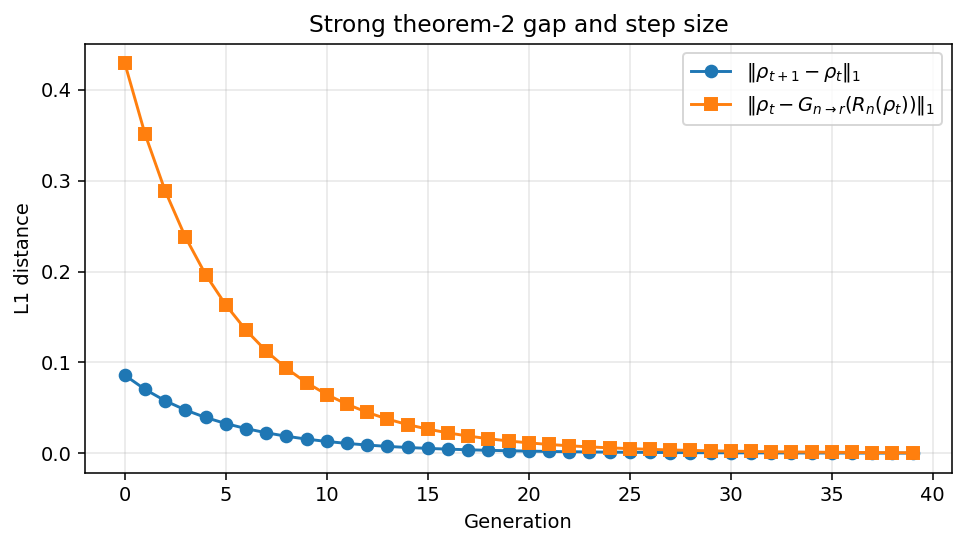

### Strong KL gap

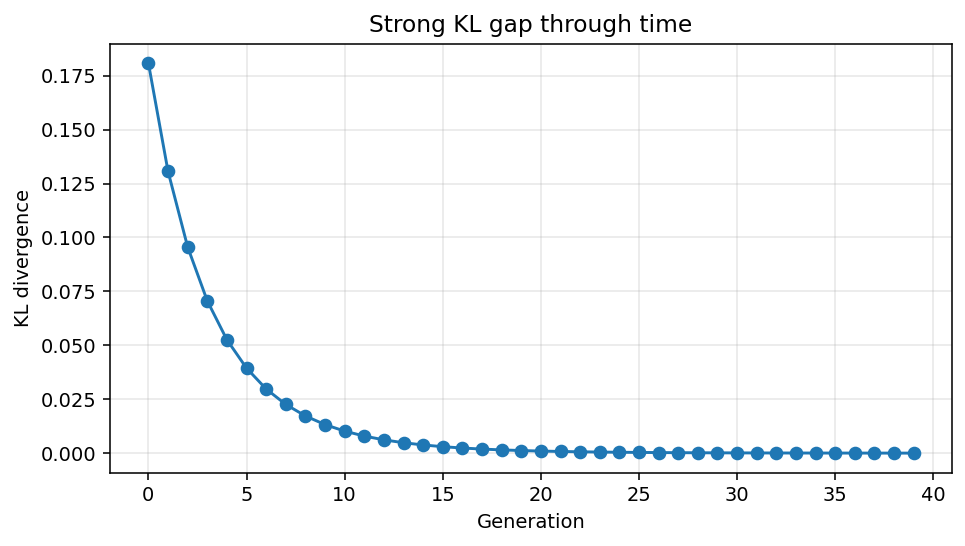

### Largest single-r-gram mismatch

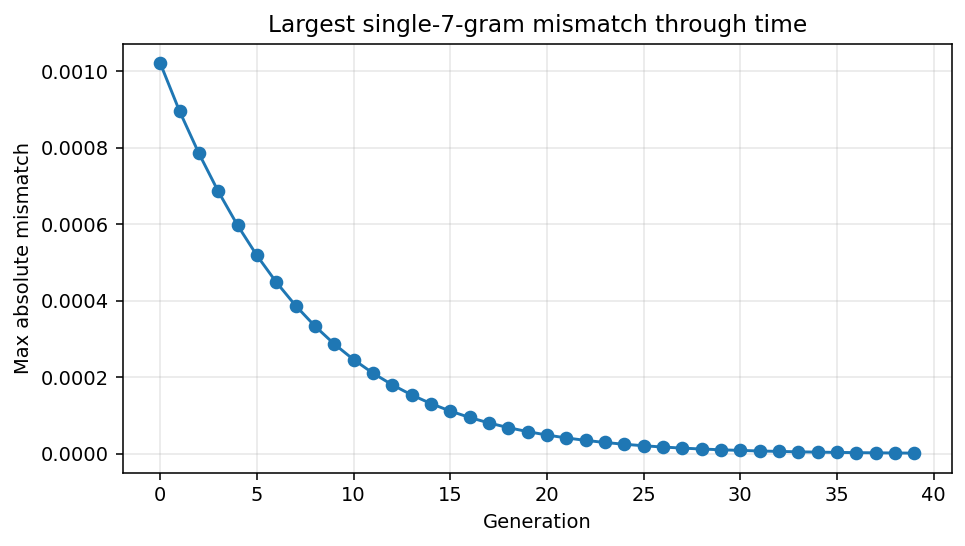

### Support sizes

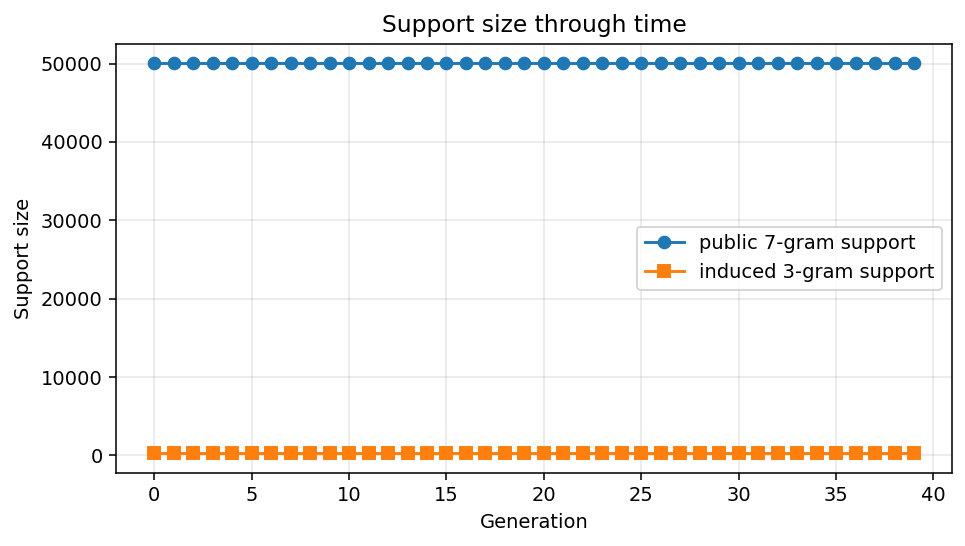

### Entropies

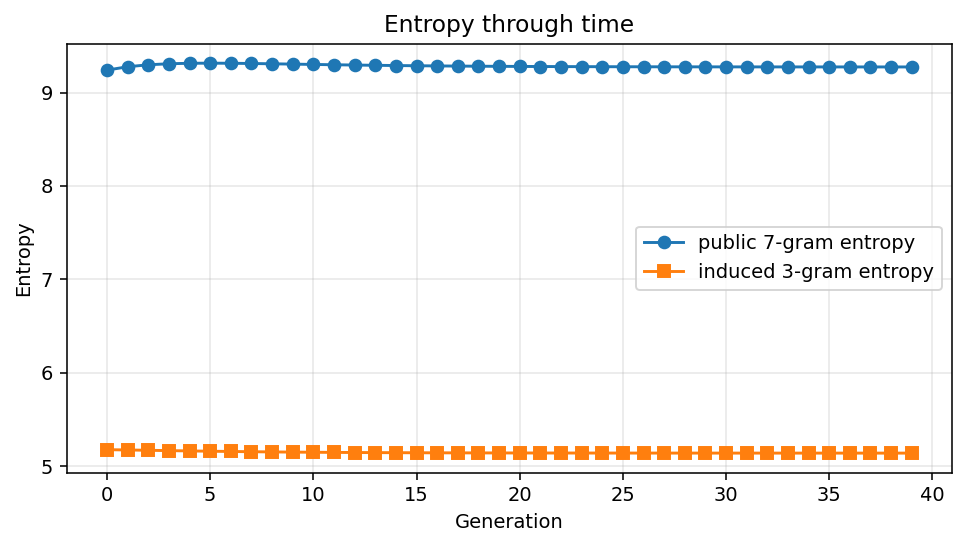

In [4]:

# --- Global diagnostic plots ---

# Plot 1: step size and strong L1 gap
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history["generation"], history["r_step_l1"], marker="o", label=r"$\|\rho_{t+1}-\rho_t\|_1$")
ax.plot(history["generation"], history["strong_gap_l1"], marker="s", label=r"$\|\rho_t-G_{n\to r}(R_n(\rho_t))\|_1$")
ax.set_xlabel("Generation")
ax.set_ylabel("L1 distance")
ax.set_title("Strong theorem-2 gap and step size")
ax.grid(True, alpha=0.3)
ax.legend()
save_plot(fig, output_dir / f"{run_tag}_plot_strong_gap_and_step.png")
display(Markdown("### Strong theorem-2 gap and step size"))
display(Image(filename=str(output_dir / f"{run_tag}_plot_strong_gap_and_step.png")))

# Plot 2: strong KL gap
kl_plot = history["strong_gap_kl"].apply(lambda x: np.nan if math.isinf(x) else x)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history["generation"], kl_plot, marker="o")
ax.set_xlabel("Generation")
ax.set_ylabel("KL divergence")
ax.set_title("Strong KL gap through time")
ax.grid(True, alpha=0.3)
save_plot(fig, output_dir / f"{run_tag}_plot_strong_kl_gap.png")
display(Markdown("### Strong KL gap"))
display(Image(filename=str(output_dir / f"{run_tag}_plot_strong_kl_gap.png")))

# Plot 3: maximum single-r-gram absolute mismatch
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history["generation"], history["max_rgram_abs_diff"], marker="o")
ax.set_xlabel("Generation")
ax.set_ylabel("Max absolute mismatch")
ax.set_title(f"Largest single-{r}-gram mismatch through time")
ax.grid(True, alpha=0.3)
save_plot(fig, output_dir / f"{run_tag}_plot_max_rgram_abs_diff.png")
display(Markdown("### Largest single-r-gram mismatch"))
display(Image(filename=str(output_dir / f"{run_tag}_plot_max_rgram_abs_diff.png")))

# Plot 4: support and entropy
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history["generation"], history["support_r"], marker="o", label=f"public {r}-gram support")
ax.plot(history["generation"], history["support_n"], marker="s", label=f"induced {n}-gram support")
ax.set_xlabel("Generation")
ax.set_ylabel("Support size")
ax.set_title("Support size through time")
ax.grid(True, alpha=0.3)
ax.legend()
save_plot(fig, output_dir / f"{run_tag}_plot_support_sizes.png")
display(Markdown("### Support sizes"))
display(Image(filename=str(output_dir / f"{run_tag}_plot_support_sizes.png")))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history["generation"], history["entropy_r"], marker="o", label=f"public {r}-gram entropy")
ax.plot(history["generation"], history["entropy_n"], marker="s", label=f"induced {n}-gram entropy")
ax.set_xlabel("Generation")
ax.set_ylabel("Entropy")
ax.set_title("Entropy through time")
ax.grid(True, alpha=0.3)
ax.legend()
save_plot(fig, output_dir / f"{run_tag}_plot_entropies.png")
display(Markdown("### Entropies"))
display(Image(filename=str(output_dir / f"{run_tag}_plot_entropies.png")))



## Prefix-conditional check

The prefix-conditional check answers a more local question:

> Once the first \(n\) tokens are fixed, do the public \(r\)-gram law and the fitted \(n\)-gram rollout
> assign the **same distribution** to the remaining \(r-n\) tokens?

For each prefix of length \(n\), the notebook computes:

- the prefix mass under the public law,
- the prefix mass under the generated law,
- the exact contribution of that prefix to the global \(L^1\) gap,
- the \(L^1\) distance between the **conditional suffix laws**,
- the KL divergence between the conditional suffix laws.

This is easier to read than the full \(r\)-gram table because it tells you **where the disagreement is coming from**.


### Top prefixes by contribution to the global gap

,prefix,public_prefix_mass,generated_prefix_mass,prefix_mass_abs_diff,prefix_l1_contribution,suffix_l1,suffix_kl,weighted_suffix_l1
0,654,0.022051,0.022067,0.000016,0.000016,2.189446e-15,8.819976e-17,4.827920e-17
1,545,0.012066,0.012077,0.000011,0.000011,2.208466e-15,1.445587e-17,2.664804e-17
2,777,0.010438,0.010428,0.000010,0.000010,1.042027e-15,0.000000e+00,1.087681e-17
3,778,0.010438,0.010428,0.000010,0.000010,1.419485e-15,0.000000e+00,1.481677e-17
4,984,0.020171,0.020181,0.000010,0.000010,1.945669e-15,4.525515e-17,3.924672e-17
5,867,0.002111,0.002102,0.000009,0.000009,9.398813e-16,0.000000e+00,1.983915e-18
6,725,0.010022,0.010030,0.000008,0.000008,2.787348e-15,1.441096e-16,2.793478e-17
7,782,0.015876,0.015869,0.000007,0.000007,1.558060e-15,0.000000e+00,2.473647e-17
8,785,0.015876,0.015869,0.000007,0.000007,1.668754e-15,0.000000e+00,2.649391e-17
9,274,0.016867,0.016860,0.000007,0.000007,2.128960e-15,0.000000e+00,3.590843e-17


Mass-weighted mean suffix L1 = 1.739912e-15. Worst prefix = 654 with prefix-L1 contribution 1.572257e-05, public prefix mass 2.205087e-02, generated prefix mass 2.206659e-02, and suffix conditional L1 2.189446e-15.


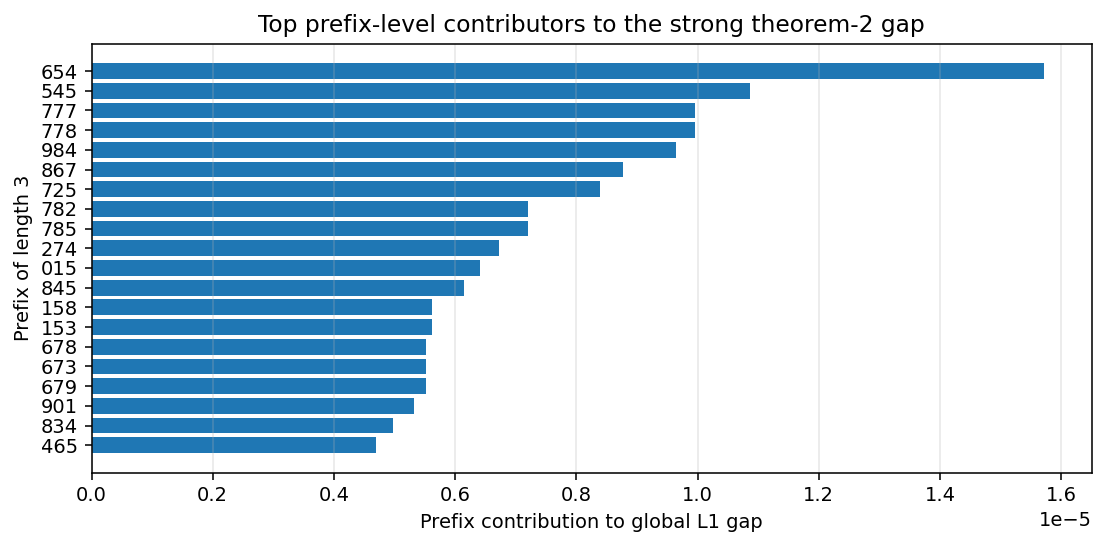

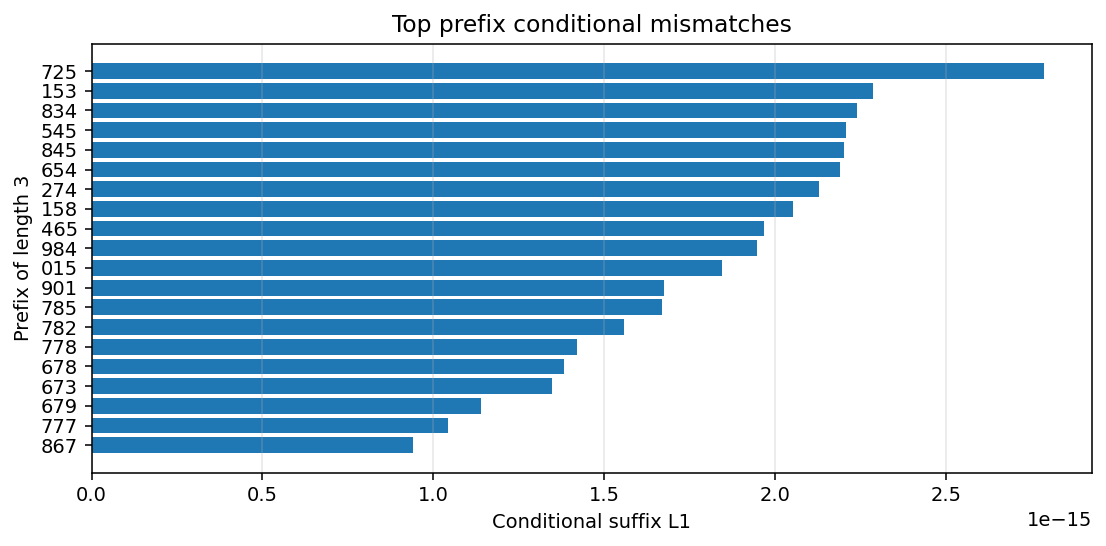

In [5]:

# --- Prefix-conditional tables and plots ---

display(Markdown("### Top prefixes by contribution to the global gap"))
display(top_prefix_df)

prefix_summary_text = summarize_prefix_check(full_prefix_df)
print(prefix_summary_text)

fig, ax = plt.subplots(figsize=(8, 4))
plot_df = top_prefix_df.sort_values("prefix_l1_contribution", ascending=True)
ax.barh(plot_df["prefix"], plot_df["prefix_l1_contribution"])
ax.set_xlabel("Prefix contribution to global L1 gap")
ax.set_ylabel(f"Prefix of length {n}")
ax.set_title("Top prefix-level contributors to the strong theorem-2 gap")
ax.grid(True, axis="x", alpha=0.3)
save_plot(fig, output_dir / f"{run_tag}_plot_top_prefix_contributors.png")
display(Image(filename=str(output_dir / f"{run_tag}_plot_top_prefix_contributors.png")))

fig, ax = plt.subplots(figsize=(8, 4))
plot_df = top_prefix_df.sort_values("suffix_l1", ascending=True)
ax.barh(plot_df["prefix"], plot_df["suffix_l1"])
ax.set_xlabel("Conditional suffix L1")
ax.set_ylabel(f"Prefix of length {n}")
ax.set_title("Top prefix conditional mismatches")
ax.grid(True, axis="x", alpha=0.3)
save_plot(fig, output_dir / f"{run_tag}_plot_top_prefix_suffix_l1.png")
display(Image(filename=str(output_dir / f"{run_tag}_plot_top_prefix_suffix_l1.png")))



## Largest mismatched \(r\)-grams

The next cell shows the exact \(r\)-grams with the largest absolute discrepancies
between the public law \(\rho_t\) and the fitted \(n\)-gram rollout law \(G_{n\to r}(R_n(\rho_t))\).

This is the most concrete diagnostic:
if these largest mismatches are tiny, then there are no important string-level counterexamples left.


### Top mismatched r-grams

,rgram,public_prob,generated_prob,signed_diff,abs_diff
0,8679015,0.000352,0.000350,1.462311e-06,1.462311e-06
1,6790158,0.002157,0.002155,1.379797e-06,1.379797e-06
2,6790153,0.002157,0.002155,1.379797e-06,1.379797e-06
3,5455067,0.001508,0.001510,-1.358551e-06,1.358551e-06
4,1539984,0.000869,0.000868,9.369270e-07,9.369270e-07
5,7901581,0.001647,0.001646,8.658218e-07,8.658218e-07
6,7901539,0.001647,0.001646,8.658218e-07,8.658218e-07
7,7901584,0.001647,0.001646,8.658218e-07,8.658218e-07
8,7901532,0.001647,0.001646,8.658218e-07,8.658218e-07
9,8455067,0.001389,0.001390,-7.672617e-07,7.672617e-07


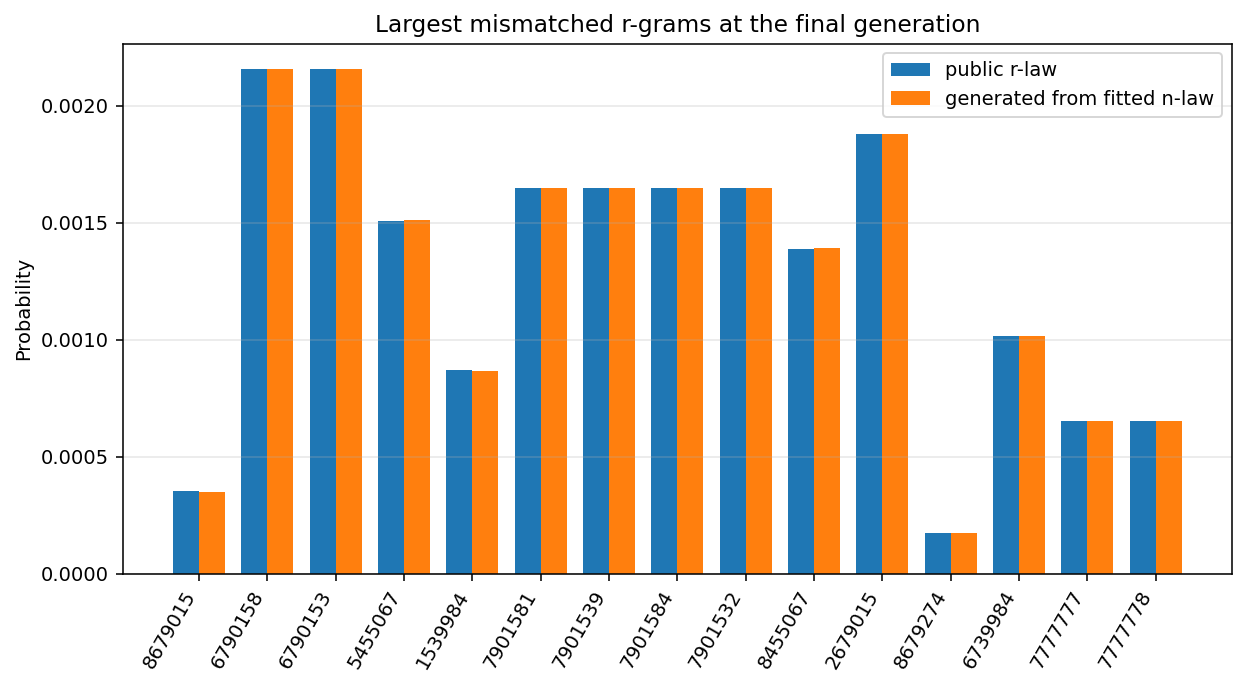

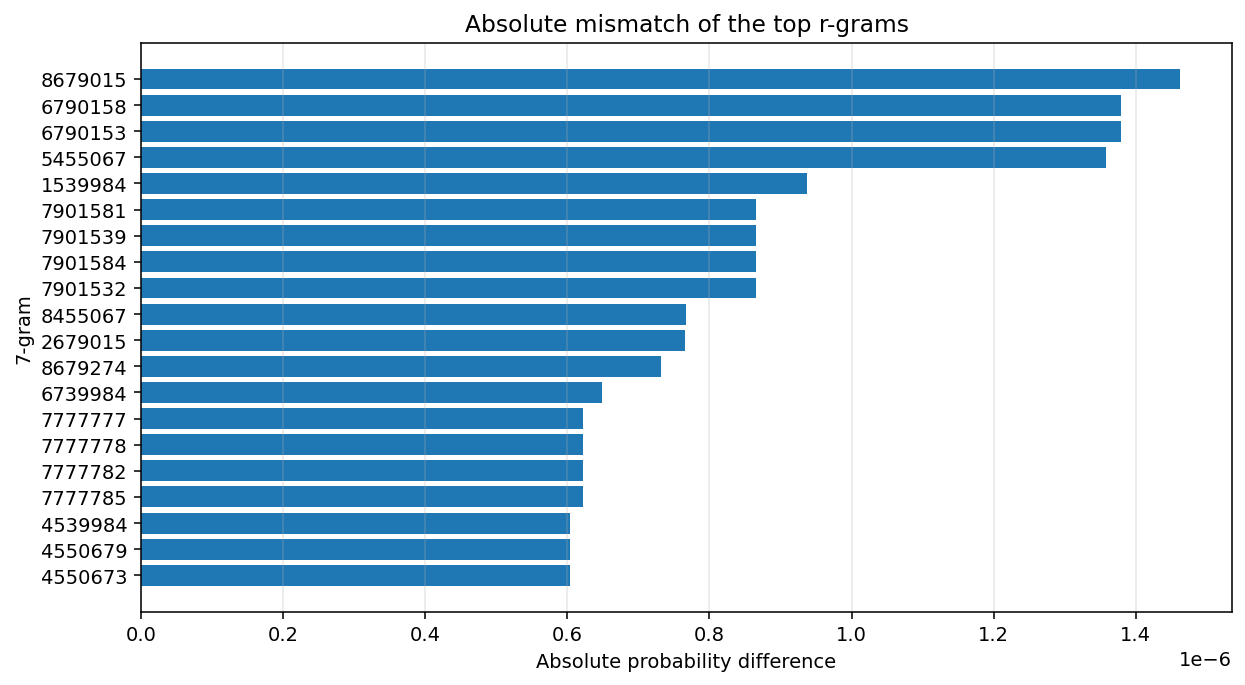

In [6]:

# --- Final top mismatched r-grams ---

display(Markdown("### Top mismatched r-grams"))
display(top_rgram_df)

fig, ax = plt.subplots(figsize=(9, 5))
plot_df = top_rgram_df.iloc[:min(15, len(top_rgram_df))].copy()
x = np.arange(len(plot_df))
w = 0.38
ax.bar(x - w/2, plot_df["public_prob"], width=w, label="public r-law")
ax.bar(x + w/2, plot_df["generated_prob"], width=w, label="generated from fitted n-law")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["rgram"], rotation=60, ha="right")
ax.set_ylabel("Probability")
ax.set_title("Largest mismatched r-grams at the final generation")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
save_plot(fig, output_dir / f"{run_tag}_plot_top_rgram_mismatches.png")
display(Image(filename=str(output_dir / f"{run_tag}_plot_top_rgram_mismatches.png")))

fig, ax = plt.subplots(figsize=(9, 5))
plot_df2 = top_rgram_df.iloc[:min(20, len(top_rgram_df))].copy().sort_values("abs_diff", ascending=True)
ax.barh(plot_df2["rgram"], plot_df2["abs_diff"])
ax.set_xlabel("Absolute probability difference")
ax.set_ylabel(f"{r}-gram")
ax.set_title("Absolute mismatch of the top r-grams")
ax.grid(True, axis="x", alpha=0.3)
save_plot(fig, output_dir / f"{run_tag}_plot_top_rgram_abs_diff.png")
display(Image(filename=str(output_dir / f"{run_tag}_plot_top_rgram_abs_diff.png")))



## Final theorem-2 reading guide

A clean positive result for the strong form of Theorem 2 looks like this:

- the **strong \(L^1\) gap** becomes very small,
- the **strong KL gap** becomes very small,
- the **prefix-conditional** discrepancies become small,
- the **largest mismatched \(r\)-grams** become tiny,
- in the default descriptive mode, the identity
  \[
  \|\rho_{t+1}-\rho_t\|_1 = \alpha(1-\beta)\,\|\rho_t-G_{n\to r}(R_n(\rho_t))\|_1
  \]
  is numerically satisfied.

If those happen, then the public \(r\)-gram law is becoming a fixed point that is also \(n\)-generated,
which is exactly the strong theorem-2 phenomenon you wanted to test.


In [7]:

# --- Final plain-English conclusion and file manifest ---

if final_strong_l1 < tol and (math.isinf(final_strong_kl) is False) and (np.nanmax(top_prefix_df["prefix_l1_contribution"].values) < tol if not top_prefix_df.empty else True):
    conclusion = (
        f"The final public {r}-gram law is numerically indistinguishable from the "
        f"{r}-gram law generated by its fitted {n}-gram predictor. "
        "This run strongly supports the strong theorem-2 fixed-point picture."
    )
elif final_strong_l1 < 1e-4:
    conclusion = (
        f"The final public {r}-gram law is very close to the "
        f"{r}-gram law generated by its fitted {n}-gram predictor, "
        "but not yet at machine-zero. This is good numerical evidence for the strong theorem-2 picture."
    )
else:
    conclusion = (
        f"The final public {r}-gram law is still visibly different from the "
        f"{r}-gram law generated by its fitted {n}-gram predictor. "
        "This run does not yet give a strong theorem-2 confirmation."
    )

display(Markdown("### Plain-English conclusion"))
print(conclusion)

manifest_rows = []
for path in sorted(output_dir.iterdir()):
    manifest_rows.append({"file": path.name, "path": str(path)})
manifest_df = pd.DataFrame(manifest_rows)
manifest_df.to_csv(output_dir / f"{run_tag}_manifest.csv", index=False)

display(Markdown("### Saved files"))
display(manifest_df)

if run_local_probe:
    probe_df = local_lipschitz_probe_rho(
        rho=rho_final,
        V=V,
        n=n,
        r=r,
        alpha_replace=alpha_replace,
        beta_mix=beta_mix,
        lookahead_mode=lookahead_mode,
        target_r=result["target_r"],
        rollout_mode=rollout_mode,
        exact_max_states=exact_max_states,
        num_rollout_samples=num_rollout_samples,
        min_context_mass=min_context_mass,
        seed=seed,
        probe_count=probe_count,
        probe_epsilon=probe_epsilon,
    )
    probe_df.to_csv(output_dir / f"{run_tag}_local_probe.csv", index=False)
    display(Markdown("### Optional local probe"))
    display(probe_df)
    print("Mean local ratio =", probe_df["ratio"].mean())
    print("Max local ratio  =", probe_df["ratio"].max())
    print("This is only a local numerical diagnostic, not a proof of contraction.")
else:
    print("Local contraction probe not run. Set run_local_probe = True to enable it.")


### Plain-English conclusion

The final public 7-gram law is still visibly different from the 7-gram law generated by its fitted 3-gram predictor. This run does not yet give a strong theorem-2 confirmation.


### Saved files

,file,path
0,thm2_V10_n3_r7_a1p0_b0p8_descPrevRDirect_seed1...,thm2_V10_n3_r7_a1p0_b0p8_descPrevRDirect_seed1...
1,thm2_V10_n3_r7_a1p0_b0p8_descPrevRDirect_seed1...,thm2_V10_n3_r7_a1p0_b0p8_descPrevRDirect_seed1...
2,thm2_V10_n3_r7_a1p0_b0p8_descPrevRDirect_seed1...,thm2_V10_n3_r7_a1p0_b0p8_descPrevRDirect_seed1...
3,thm2_V10_n3_r7_a1p0_b0p8_descPrevRDirect_seed1...,thm2_V10_n3_r7_a1p0_b0p8_descPrevRDirect_seed1...
4,thm2_V10_n3_r7_a1p0_b0p8_descPrevRDirect_seed1...,thm2_V10_n3_r7_a1p0_b0p8_descPrevRDirect_seed1...
5,thm2_V10_n3_r7_a1p0_b0p8_descPrevRDirect_seed1...,thm2_V10_n3_r7_a1p0_b0p8_descPrevRDirect_seed1...
6,thm2_V10_n3_r7_a1p0_b0p8_descPrevRDirect_seed1...,thm2_V10_n3_r7_a1p0_b0p8_descPrevRDirect_seed1...
7,thm2_V10_n3_r7_a1p0_b0p8_descPrevRDirect_seed1...,thm2_V10_n3_r7_a1p0_b0p8_descPrevRDirect_seed1...
8,thm2_V10_n3_r7_a1p0_b0p8_descPrevRDirect_seed1...,thm2_V10_n3_r7_a1p0_b0p8_descPrevRDirect_seed1...
9,thm2_V10_n3_r7_a1p0_b0p8_descPrevRDirect_seed1...,thm2_V10_n3_r7_a1p0_b0p8_descPrevRDirect_seed1...


Local contraction probe not run. Set run_local_probe = True to enable it.
